In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/df_transaction_clean.csv')
df.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,mcc_code,categoria
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,Sin Error,5499,Miscellaneous Food Stores
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,Sin Error,5311,Department Stores
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,Sin Error,4829,Money Transfer
3,7475331,2010-01-01 00:05:00,430,2860,200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,Sin Error,4829,Money Transfer
4,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,Sin Error,5813,Drinking Places (Alcoholic Beverages)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 14 columns):
 #   Column          Dtype  
---  ------          -----  
 0   id              int64  
 1   date            object 
 2   client_id       int64  
 3   card_id         int64  
 4   amount          float64
 5   use_chip        object 
 6   merchant_id     int64  
 7   merchant_city   object 
 8   merchant_state  object 
 9   zip             object 
 10  mcc             int64  
 11  errors          object 
 12  mcc_code        int64  
 13  categoria       object 
dtypes: float64(1), int64(6), object(7)
memory usage: 1.4+ GB


### Pregunta 6 - ¿Cuál es la Categoría de gasto con mayor monto acumaldo?
- La categoria con mayor gasto es Money Transfer con un total de $53,158,515.64 en movimientos

In [9]:
df_gasto = df[df["amount"] > 0 ]

gasto_cat = (df_gasto
            .groupby('categoria')['amount']
            .sum()
            .sort_values(ascending = False)
            )
gasto_cat.head()

categoria
Money Transfer                  53158515.64
Service Stations                51239755.42
Grocery Stores, Supermarkets    40970767.06
Wholesale Clubs                 37697568.71
Miscellaneous Food Stores       37352646.05
Name: amount, dtype: float64

### Pregunta 7 - ¿Cuál es el promedio de transacción por categoría?
- Categoria con mejores promedios
    - Cruise Lines  --- 1551.42%
    - Steel Drums and Barrels ---   797.89%
    - Fabricated Structural Metal Products ---   786.94%
- Categoria con peores promedios
    -  Gift, Card, Novelty Stores ---    11.28%
    -  Miscellaneous Food Stores   ---  10.65%
    -  Package Stores, Beer, Wine, Liquor ---    10.55%

In [20]:
promedio_cat = (df
    .groupby('categoria')['amount']
    .mean()
    .round(2)
    .sort_values(ascending = False)
    .reset_index()
    
)
promedio_cat.columns = ['Categoria', 'Promedio']
print("Top 3 \n", promedio_cat.head(3))
print("Button 3 \n", promedio_cat.tail(3))

Top 3 
                               Categoria  Promedio
0                          Cruise Lines   1551.42
1               Steel Drums and Barrels    797.89
2  Fabricated Structural Metal Products    786.94
Button 3 
                               Categoria  Promedio
105          Gift, Card, Novelty Stores     11.28
106           Miscellaneous Food Stores     10.65
107  Package Stores, Beer, Wine, Liquor     10.55


In [15]:
# Estadistica de los promedios
promedio_cat['Promedio'].describe()

count     108.000000
mean      219.259722
std       285.397889
min        10.550000
25%        45.395000
50%        78.985000
75%       182.087500
max      1551.420000
Name: Promedio, dtype: float64

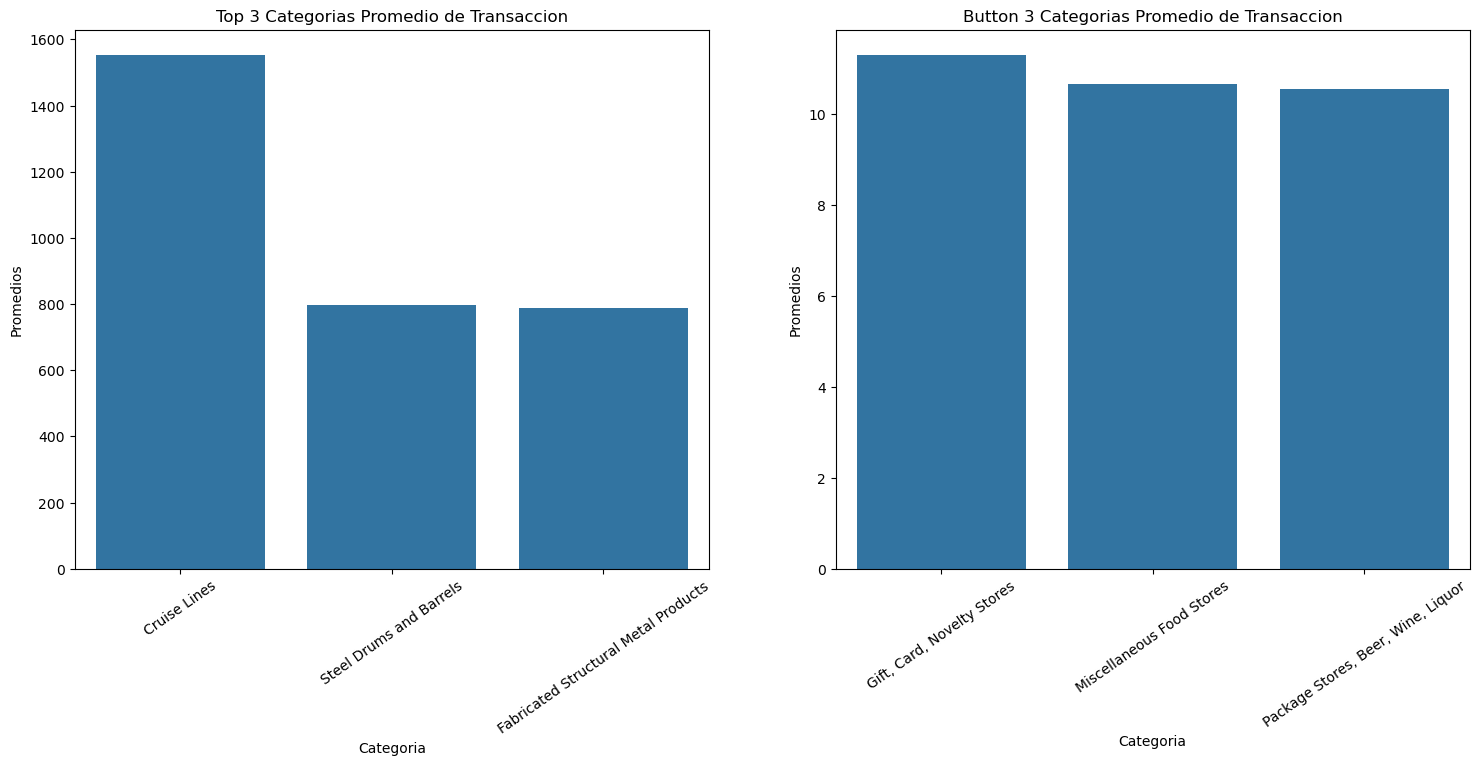

In [25]:
top_3_cat = promedio_cat.head(3)
button_3_cat = promedio_cat.tail(3)

fig, ax = plt.subplots(1,2, figsize=(18,7))
sns.barplot(data=top_3_cat, x='Categoria', y='Promedio', ax=ax[0])
ax[0].set_title('Top 3 Categorias Promedio de Transaccion')
ax[0].set_ylabel('Promedios')
ax[0].tick_params(axis='x', rotation=35)

sns.barplot(data=button_3_cat, x='Categoria', y='Promedio', ax=ax[1])
ax[1].set_title('Button 3 Categorias Promedio de Transaccion')
ax[1].set_ylabel('Promedios')
ax[1].tick_params(axis='x', rotation=35)


### Pregunta 8 - ¿Qué mes del año concentra más volumen de transacciones en monto?
- El mes con mas volumen de transacciones es Julio
- Estos son las 5 meses con mayor monto de transacciones:

| Año | Mes | Monto |
| --- | --- | --- |
| 2016 | Julio | 5123666.67 |
| 2017 | Julio | 5115221.54 |
| 2015 |	Diciembre | 5111632.82 |
| 2018 | Julio | 5107278.77 |
|2017 | Mayo | 5097755.38 |

In [27]:
df['date'] = pd.to_datetime(df['date'])

df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

In [28]:
meses = {1:'Enero', 2:'Febrero', 3:'Marzo', 4:'Abril',5:'Mayo', 6:'Junio', 7:'Julio', 8:'Agosto',9:'Septiembre', 10:'Octubre', 
         11:'Noviembre', 12:'Diciembre'}

In [29]:
mes_transaction = (df
    .groupby(['year','month'])['amount']
    .sum()
    .sort_values(ascending = False)
    .round(2)
    .reset_index()
)
mes_transaction['Mes'] = mes_transaction['month'].map(meses)
mes_transaction.head()

,year,month,amount,Mes
0,2016,7,5123666.67,Julio
1,2017,7,5115221.54,Julio
2,2015,12,5111632.82,Diciembre
3,2018,7,5107278.77,Julio
4,2017,5,5097755.38,Mayo


### Pregunta 9 - ¿Cuánto representa cada categoria como porcentaje total?

In [42]:
total = promedio_cat["Promedio"].sum()

promedio_cat["Porcentaje"] = (promedio_cat['Promedio'] / total * 100).round(2)
print(promedio_cat.head(3))
print(promedio_cat.tail(3))

                              Categoria  Promedio  Porcentaje
0                          Cruise Lines   1551.42        6.55
1               Steel Drums and Barrels    797.89        3.37
2  Fabricated Structural Metal Products    786.94        3.32
                              Categoria  Promedio  Porcentaje
105          Gift, Card, Novelty Stores     11.28        0.05
106           Miscellaneous Food Stores     10.65        0.04
107  Package Stores, Beer, Wine, Liquor     10.55        0.04


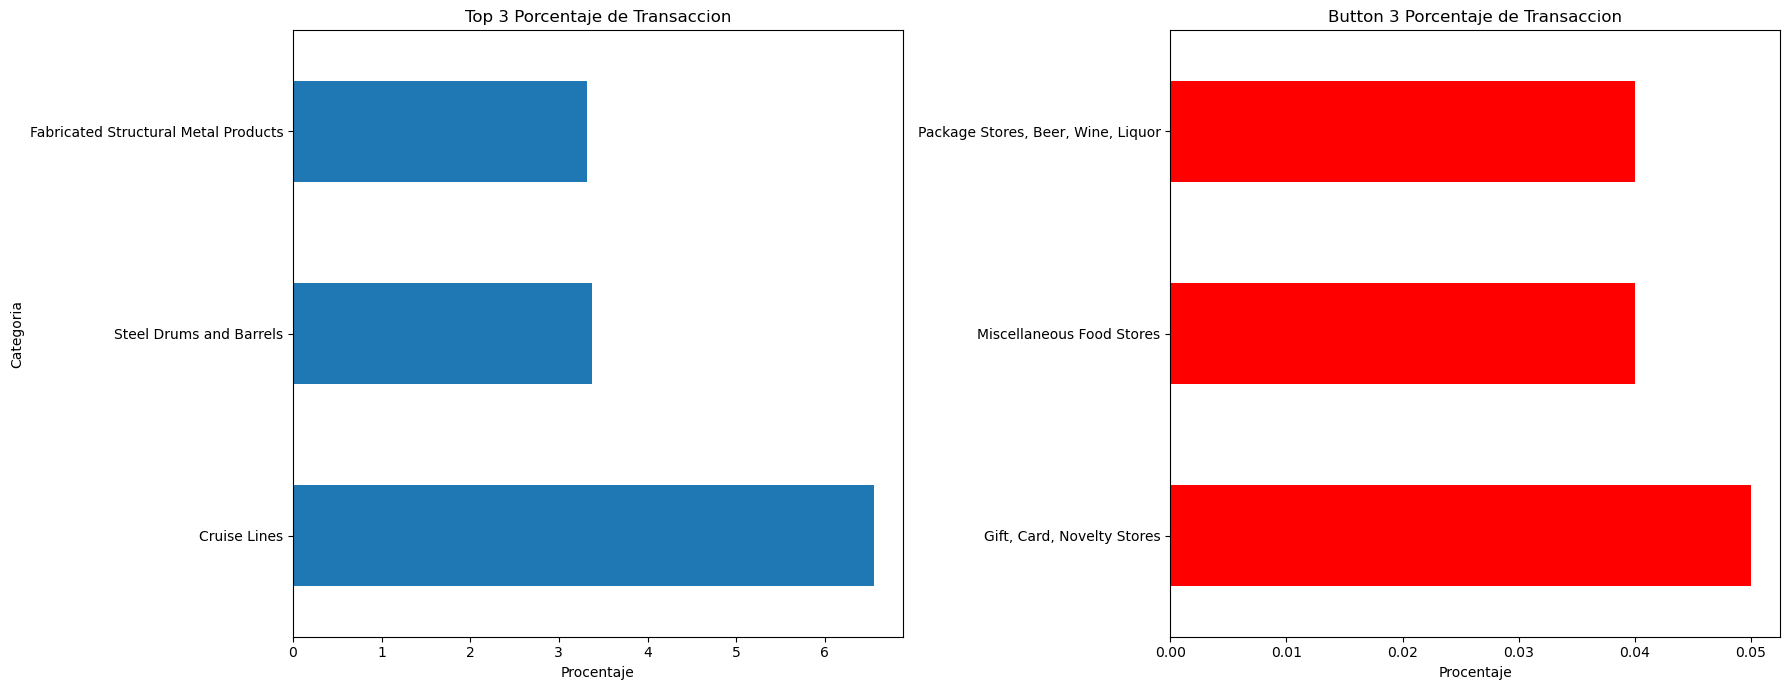

In [41]:
top_3_porcentaje = promedio_cat.head(3)
button_3_porcentaje = promedio_cat.tail(3)

#Representacion Grafica

fig, ax = plt.subplots(1,2, figsize=(18,7))
top_3_porcentaje.plot(x='Categoria', y='Porcentaje', kind='barh', legend= False, ax=ax[0])
ax[0].set_title('Top 3 Porcentaje de Transaccion')
ax[0].set_ylabel('Categoria')
ax[0].set_xlabel('Procentaje')


button_3_porcentaje.plot(x='Categoria', y='Porcentaje', kind='barh', legend= False, ax=ax[1], color='red')
ax[1].set_title('Button 3 Porcentaje de Transaccion')
ax[1].set_xlabel('Procentaje')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

### Pregunta 10 - ¿Cuáles son los 10 clientes (o comercios) con mayor gasto total?

In [46]:
cliente_gasto = (df_gasto
    .groupby('client_id')['amount']
    .sum()
    .sort_values(ascending = False)
    .reset_index()
)
cliente_gasto.columns = ['id','gasto']
cliente_gasto.head()

,id,gasto
0,96,3002117.15
1,1888,2288609.28
2,1098,2249029.53
3,1686,2212751.90
4,1168,2116564.75


In [47]:
user_data = pd.read_csv('../data/df_user_clean.csv')
user_data.head()

,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,29278,59696,127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,37891,77254,191349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,22681,33483,196,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,163145,249925,202328,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,53797,109687,183855,675,1


In [49]:
cols_interes = ['id','current_age', 'gender', 'yearly_income', 'total_debt', 'credit_score']
top_10_client = cliente_gasto.merge(user_data[cols_interes], on='id', how='left')
top_10_client.head(10)

,id,gasto,current_age,gender,yearly_income,total_debt,credit_score
0,96,3002117.15,69,Female,99825,4344,685
1,1888,2288609.28,75,Female,41513,15899,748
2,1098,2249029.53,50,Male,34456,54634,752
3,1686,2212751.90,54,Female,61312,25355,708
4,1168,2116564.75,51,Male,109673,242379,505
5,1340,2104526.23,53,Male,53872,64269,691
6,840,2029513.85,68,Female,88432,63075,694
7,464,1926015.35,36,Male,67444,93513,850
8,1776,1869408.82,47,Male,43133,44263,693
9,490,1772334.84,86,Male,33426,1852,699


In [50]:
top_10_client['ratio_gasto_ingreso'] = (top_10_client['gasto']/top_10_client['yearly_income']).round(2)
top_10_client.head()

,id,gasto,current_age,gender,yearly_income,total_debt,credit_score,ratio_gasto_ingreso
0,96,3002117.15,69,Female,99825,4344,685,30.07
1,1888,2288609.28,75,Female,41513,15899,748,55.13
2,1098,2249029.53,50,Male,34456,54634,752,65.27
3,1686,2212751.90,54,Female,61312,25355,708,36.09
4,1168,2116564.75,51,Male,109673,242379,505,19.30


In [52]:
alerta = top_10_client[top_10_client['ratio_gasto_ingreso'] > 1]
print(f"Clientes con gasto mayor a su ingreso anual: {len(alerta)}")

Clientes con gasto mayor a su ingreso anual: 1216


In [54]:
top_10_tiendas = (df_gasto
    .groupby(['merchant_id','categoria'])['amount']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
top_10_tiendas.columns = ['tienda_id', 'categoria','gasto']
top_10_tiendas.head(10)

,tienda_id,categoria,gasto
0,27092,Money Transfer,53158515.64
1,59935,Miscellaneous Food Stores,22324926.51
2,61195,Service Stations,20582850.60
3,60569,Wholesale Clubs,18900009.49
4,39021,Tolls and Bridge Fees,15725411.29
5,43293,Miscellaneous Food Stores,13503080.05
6,22204,Service Stations,12578334.39
7,73186,Telecommunication Services,11664827.54
8,20561,Drug Stores and Pharmacies,8995666.10
9,50783,"Grocery Stores, Supermarkets",7717216.83


In [56]:
# df para visualizaciones
df_gasto.to_csv(r"C:\Users\Personal\Documents\PythonDataAnalisis\Portafolio\Python_Projects\Analisis Financiero\data\df_gasto.csv", index=False)
top_10_client.to_csv(r"C:\Users\Personal\Documents\PythonDataAnalisis\Portafolio\Python_Projects\Analisis Financiero\data\df_client_gasto.csv", index=False)
top_10_tiendas.to_csv(r"C:\Users\Personal\Documents\PythonDataAnalisis\Portafolio\Python_Projects\Analisis Financiero\data\df_tiendas_gasto.csv", index=False)